In [2]:
!pip install numpy scipy

In [3]:
import numpy as np
import scipy

In [5]:
import numpy as np
from scipy.optimize import linprog

def solve_box_lp(c, A, b, l_bounds, u_bounds, int_idx, tau=1.0):
    n = len(c)
    m = 2 * n
    obj = np.zeros(m)
    obj[:n] = -c
    obj[n:] = -c

    A_ub = []
    b_ub = []

    for i in range(n):
        row = np.zeros(m)
        row[i] = 1.0
        row[n + i] = -1.0
        A_ub.append(row)
        b_ub.append(0.0)

    for i in int_idx:
        row = np.zeros(m)
        row[i] = 1.0
        row[n + i] = -1.0
        A_ub.append(row)
        b_ub.append(-tau)

    for k in range(len(b)):
        row = np.zeros(m)
        for i in range(n):
            a = A[k, i]
            if a >= 0:
                row[n + i] += a
            else:
                row[i] += a
        A_ub.append(row)
        b_ub.append(b[k])

    bounds = [(l_bounds[i], u_bounds[i]) for i in range(n)] + [(l_bounds[i], u_bounds[i]) for i in range(n)]

    res = linprog(obj, A_ub=np.array(A_ub), b_ub=np.array(b_ub), bounds=bounds, method='highs')
    if not res.success:
        return None
    l = res.x[:n]
    u = res.x[n:]
    return l, u, -res.fun

def build_candidate(c, l, u, int_idx):
    x = np.zeros(len(c))
    int_set = set(int_idx)
    for i in range(len(c)):
        if i in int_set:
            x[i] = np.floor(u[i]) if c[i] >= 0 else np.ceil(l[i])
            if x[i] < l[i] or x[i] > u[i]:
                return None
        else:
            x[i] = u[i] if c[i] >= 0 else l[i]
    return x

def check_feasible(A, b, x, tol=1e-7):
    return np.all(A @ x <= b + tol)

def inner_box_search(c, A, b, l_bounds, u_bounds, int_idx, tau=1.0):
    sol = solve_box_lp(c, A, b, l_bounds, u_bounds, int_idx, tau=tau)
    if sol is None:
        return {'status': 'infeasible_box_lp'}
    l, u, obj = sol
    x = build_candidate(c, l, u, int_idx)
    feasible = x is not None and check_feasible(A, b, x)
    return {
        'status': 'ok',
        'l': l,
        'u': u,
        'center': (l + u) / 2,
        'candidate': x,
        'candidate_feasible': feasible,
        'box_objective': obj,
    }


c = np.array([3.0, 2.0, 1.0])
A = np.array([
    [2.0, 1.0, 1.0],
    [1.0, 2.0, 0.0],
    [0.0, 1.0, 2.0],
])
b = np.array([4.5, 4.0, 3.5])
l_bounds = np.array([0.0, 0.0, 0.0])
u_bounds = np.array([3.0, 3.0, 3.0])
int_idx = [0, 1]

result = inner_box_search(c, A, b, l_bounds, u_bounds, int_idx, tau=1.0)
print('Status:', result['status'])
if result['status'] == 'ok':
    print('l =', np.round(result['l'], 4))
    print('u =', np.round(result['u'], 4))
    print('center =', np.round(result['center'], 4))
    print('candidate =', np.round(result['candidate'], 4) if result['candidate'] is not None else None)
    print('candidate feasible =', result['candidate_feasible'])
    print('box objective =', round(result['box_objective'], 6))

Status: ok
l = [ 0.6667  0.1667 -0.    ]
u = [1.6667 1.1667 0.    ]
center = [1.1667 0.6667 0.    ]
candidate = [1. 1. 0.]
candidate feasible = True
box objective = 9.666667


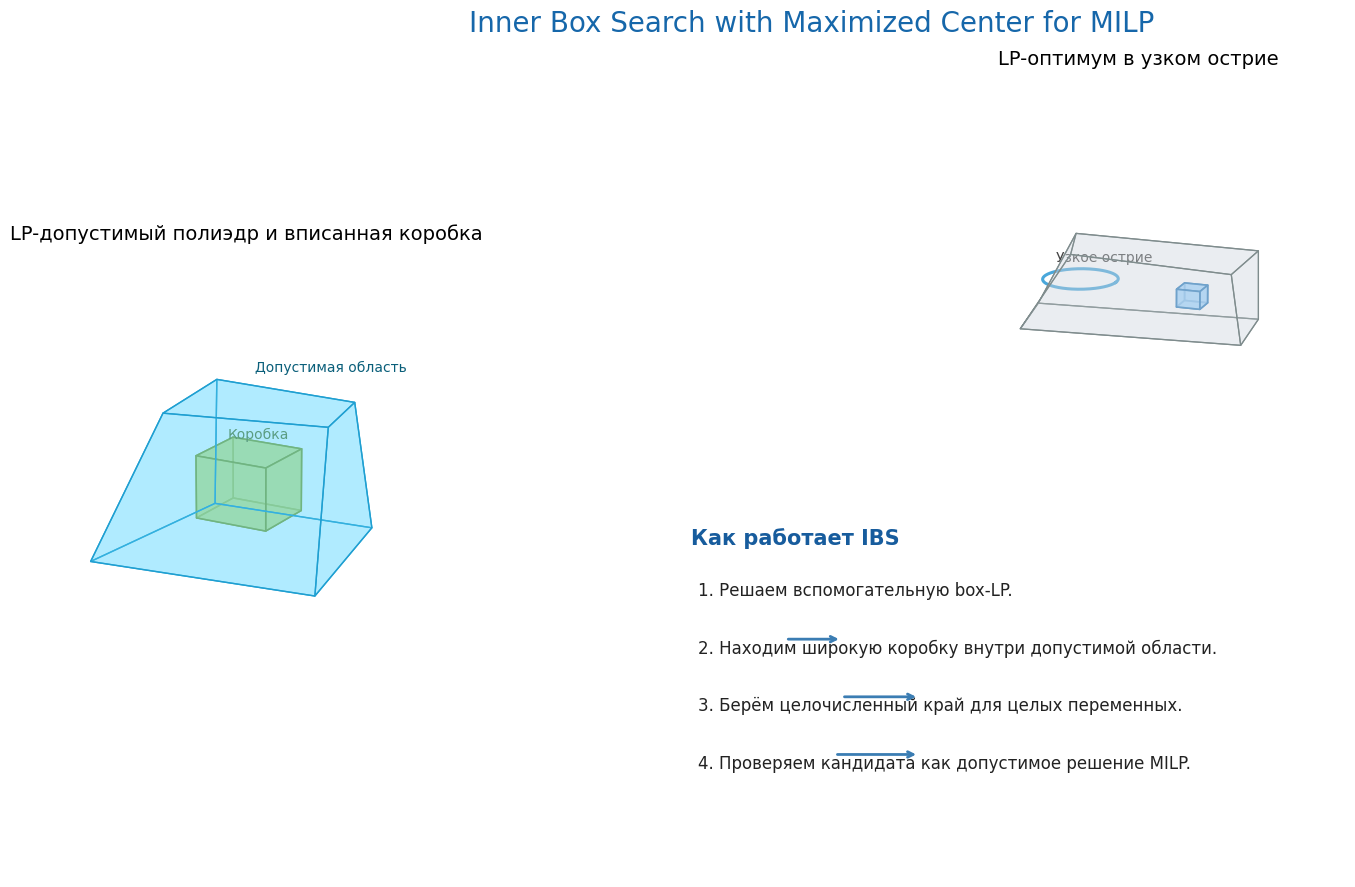

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# ---------- helpers ----------
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    r = 0.5 * max([x_range, y_range, z_range])
    x_mid = np.mean(x_limits)
    y_mid = np.mean(y_limits)
    z_mid = np.mean(z_limits)
    ax.set_xlim3d([x_mid - r, x_mid + r])
    ax.set_ylim3d([y_mid - r, y_mid + r])
    ax.set_zlim3d([z_mid - r, z_mid + r])

def add_polyhedron(ax, verts, faces, color="#6fd3ff", alpha=0.28, edgecolor="#2b8cbe", lw=1.0):
    poly = Poly3DCollection([verts[f] for f in faces], facecolors=color, edgecolors=edgecolor, linewidths=lw, alpha=alpha)
    ax.add_collection3d(poly)

def add_box(ax, l, u, color="#b7d34a", alpha=0.55, edgecolor="#5c7a00", lw=1.2):
    x0, y0, z0 = l
    x1, y1, z1 = u
    v = np.array([
        [x0, y0, z0],
        [x1, y0, z0],
        [x1, y1, z0],
        [x0, y1, z0],
        [x0, y0, z1],
        [x1, y0, z1],
        [x1, y1, z1],
        [x0, y1, z1],
    ])
    faces = [
        [0,1,2,3], [4,5,6,7], [0,1,5,4],
        [2,3,7,6], [1,2,6,5], [3,0,4,7]
    ]
    poly = Poly3DCollection([v[f] for f in faces], facecolors=color, edgecolors=edgecolor, linewidths=lw, alpha=alpha)
    ax.add_collection3d(poly)
    return v

def annotate3d(ax, text, xyz, color="black", size=9):
    ax.text(xyz[0], xyz[1], xyz[2], text, color=color, fontsize=size)

# ---------- figure ----------
fig = plt.figure(figsize=(16, 9), facecolor="white")
gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1], width_ratios=[1.25, 1, 1])

ax1 = fig.add_subplot(gs[:, 0], projection="3d")
ax2 = fig.add_subplot(gs[0, 1:], projection="3d")
ax3 = fig.add_subplot(gs[1, 1])

# ---------- left: polyhedron + box ----------
verts1 = np.array([
    [0.0, 0.0, 0.0],
    [3.4, 0.2, 0.1],
    [2.9, 2.8, 0.2],
    [0.2, 3.0, 0.0],
    [0.7, 0.8, 2.7],
    [3.2, 0.9, 2.9],
    [2.6, 2.8, 2.6],
    [0.6, 2.4, 2.8],
])
faces1 = [
    [0,1,2,3], [4,5,6,7], [0,1,5,4],
    [1,2,6,5], [2,3,7,6], [3,0,4,7]
]
add_polyhedron(ax1, verts1, faces1, color="#66d9ff", alpha=0.30, edgecolor="#1f9fd1", lw=1.0)
add_box(ax1, l=[1.1, 1.0, 0.7], u=[2.2, 2.0, 1.9], color="#c9d94d", alpha=0.60, edgecolor="#7c8f00", lw=1.1)
ax1.set_title("LP-допустимый полиэдр и вписанная коробка", fontsize=14, pad=16)
ax1.set_axis_off()
ax1.view_init(elev=18, azim=-60)
set_axes_equal(ax1)
annotate3d(ax1, "Допустимая область", [1.0, 2.8, 2.9], color="#0a5f7a", size=10)
annotate3d(ax1, "Коробка", [1.4, 1.35, 2.15], color="#4f5f00", size=10)

# ---------- right top: narrow tip + circle ----------
verts2 = np.array([
    [0.1, 0.2, 0.2],
    [3.7, 0.8, 0.1],
    [3.9, 1.1, 0.6],
    [0.3, 0.5, 0.7],
    [0.8, 0.7, 1.8],
    [3.4, 1.2, 1.5],
    [3.7, 1.7, 1.9],
    [0.7, 1.2, 2.1],
])
add_polyhedron(ax2, verts2, faces1, color="#cfd6de", alpha=0.23, edgecolor="#7f8c8d", lw=0.9)
add_box(ax2, l=[2.55, 0.95, 0.75], u=[2.95, 1.35, 1.15], color="#9fd4ff", alpha=0.75, edgecolor="#2f7fbf", lw=1.2)
theta = np.linspace(0, 2*np.pi, 200)
cx, cy, cz = 0.95, 0.75, 1.25
r = 0.62
ax2.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), cz + 0*theta, color="#49a7db", lw=2.2)
ax2.set_title("LP-оптимум в узком острие", fontsize=14, pad=16)
ax2.set_axis_off()
ax2.view_init(elev=16, azim=-70)
set_axes_equal(ax2)
annotate3d(ax2, "Узкое острие", [0.6, 0.55, 1.65], color="#444444", size=10)

# ---------- bottom right: conceptual flow ----------
ax3.axis("off")
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.text(0.03, 0.92, "Как работает IBS", fontsize=15, fontweight="bold", color="#175c9d")
steps = [
    "1. Решаем вспомогательную box-LP.",
    "2. Находим широкую коробку внутри допустимой области.",
    "3. Берём целочисленный край для целых переменных.",
    "4. Проверяем кандидата как допустимое решение MILP.",
    ]
y = 0.78
for s in steps:
    ax3.text(0.05, y, s, fontsize=12, color="#222222")
    y -= 0.16

ax3.annotate("", xy=(0.46, 0.66), xytext=(0.30, 0.66),
             arrowprops=dict(arrowstyle="->", lw=2, color="#3b7db3"))
ax3.annotate("", xy=(0.68, 0.50), xytext=(0.46, 0.50),
             arrowprops=dict(arrowstyle="->", lw=2, color="#3b7db3"))
ax3.annotate("", xy=(0.44, 0.34), xytext=(0.68, 0.34),
             arrowprops=dict(arrowstyle="<-", lw=2, color="#3b7db3"))

plt.suptitle("Inner Box Search with Maximized Center for MILP", fontsize=20, y=0.98, color="#1667aa")
plt.tight_layout()
plt.show()